In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# LOAD FINAL SIMULATION RESULTS
# ---------------------------------------

all_results = pd.read_csv(
    "../data/nba_championship_probabilities_1993_2025.csv"
)

champions = pd.read_csv(
    "../data/nba_actual_champion_probabilities_1993_2025.csv"
)

franchises = pd.read_csv(
    "../data/nba_franchise_expected_vs_actual_1993_2025.csv"
)

print("Data loaded successfully.")

print("\nAll playoff team-seasons:")
print(all_results.shape)

print("\nActual champions:")
print(champions.shape)

print("\nFranchises:")
print(franchises.shape)

Data loaded successfully.

All playoff team-seasons:
(528, 5)

Actual champions:
(33, 8)

Franchises:
(30, 5)


In [2]:
print("Champion seasons:")
print(
    champions["Season_End"].min(),
    "to",
    champions["Season_End"].max()
)

print(
    "\nLowest champion probability:",
    champions["Championship_Probability"].min()
)

print(
    "Highest champion probability:",
    champions["Championship_Probability"].max()
)

champions.sort_values(
    "Championship_Probability"
).head(10)

Champion seasons:
1993 to 2025

Lowest champion probability: 0.0025
Highest champion probability: 0.7535


,Season,Season_End,Champion,Wins,Losses,SRS,Simulated_Championships,Championship_Probability
0,1994-95,1995,Houston Rockets,47,35,2.32,25,0.0025
1,2000-01,2001,Los Angeles Lakers,56,26,3.74,362,0.0362
2,2005-06,2006,Miami Heat,52,30,3.59,366,0.0366
3,2010-11,2011,Dallas Mavericks,57,25,4.41,378,0.0378
4,1993-94,1994,Houston Rockets,58,24,4.19,457,0.0457
5,2009-10,2010,Los Angeles Lakers,57,25,4.78,706,0.0706
6,2015-16,2016,Cleveland Cavaliers,57,25,5.45,716,0.0716
7,2022-23,2023,Denver Nuggets,53,29,3.04,875,0.0875
8,2021-22,2022,Golden State Warriors,53,29,5.52,947,0.0947
9,2017-18,2018,Golden State Warriors,58,24,5.79,974,0.0974


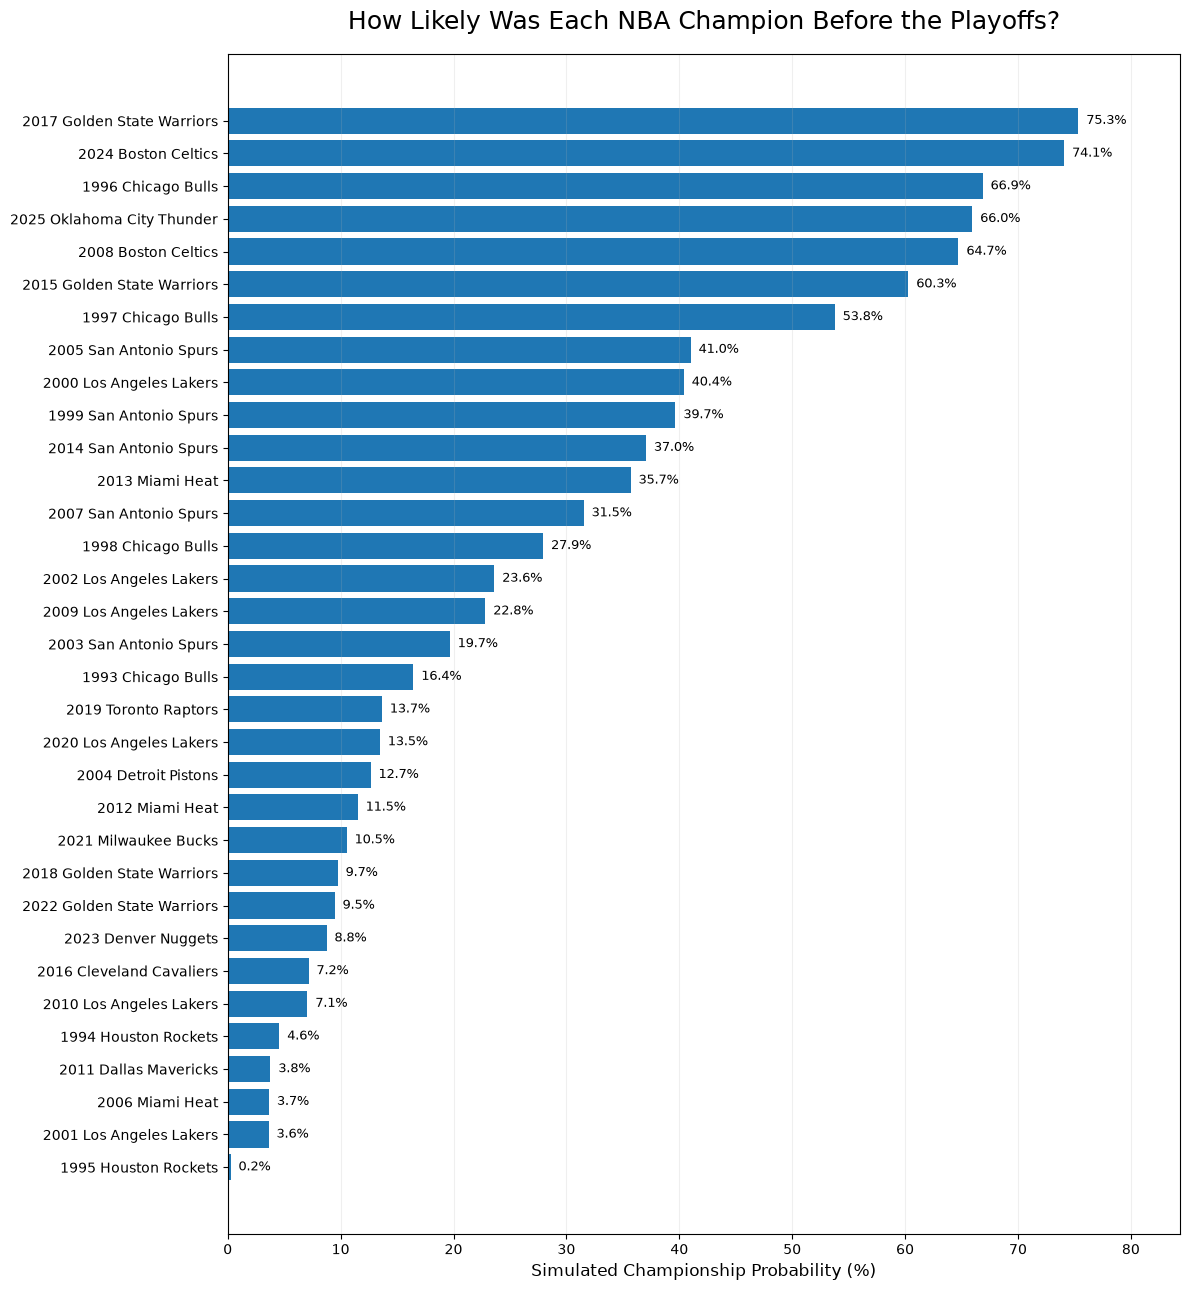

In [3]:
# ============================================================
# FIGURE 1
# PRE-PLAYOFF CHAMPIONSHIP PROBABILITY
# OF EVERY NBA CHAMPION, 1993-2025
# ============================================================

champion_plot = (
    champions
    .sort_values(
        "Championship_Probability",
        ascending=False
    )
    .copy()
)

# Label: "1995 Rockets", "2001 Lakers", etc.
champion_plot["Label"] = (
    champion_plot["Season_End"].astype(str)
    + " "
    + champion_plot["Champion"]
)

fig, ax = plt.subplots(
    figsize=(12, 13)
)

bars = ax.barh(
    champion_plot["Label"],
    champion_plot["Championship_Probability"] * 100
)

# Put most improbable champion at top
ax.invert_yaxis()

# Percentage labels
for bar, probability in zip(
    bars,
    champion_plot["Championship_Probability"]
):
    ax.text(
        bar.get_width() + 0.7,
        bar.get_y() + bar.get_height() / 2,
        f"{probability:.1%}",
        va="center",
        fontsize=9
    )

ax.set_title(
    "How Likely Was Each NBA Champion Before the Playoffs?",
    fontsize=18,
    pad=18
)

ax.set_xlabel(
    "Simulated Championship Probability (%)",
    fontsize=12
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    champion_plot[
        "Championship_Probability"
    ].max() * 100 + 9
)

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.show()

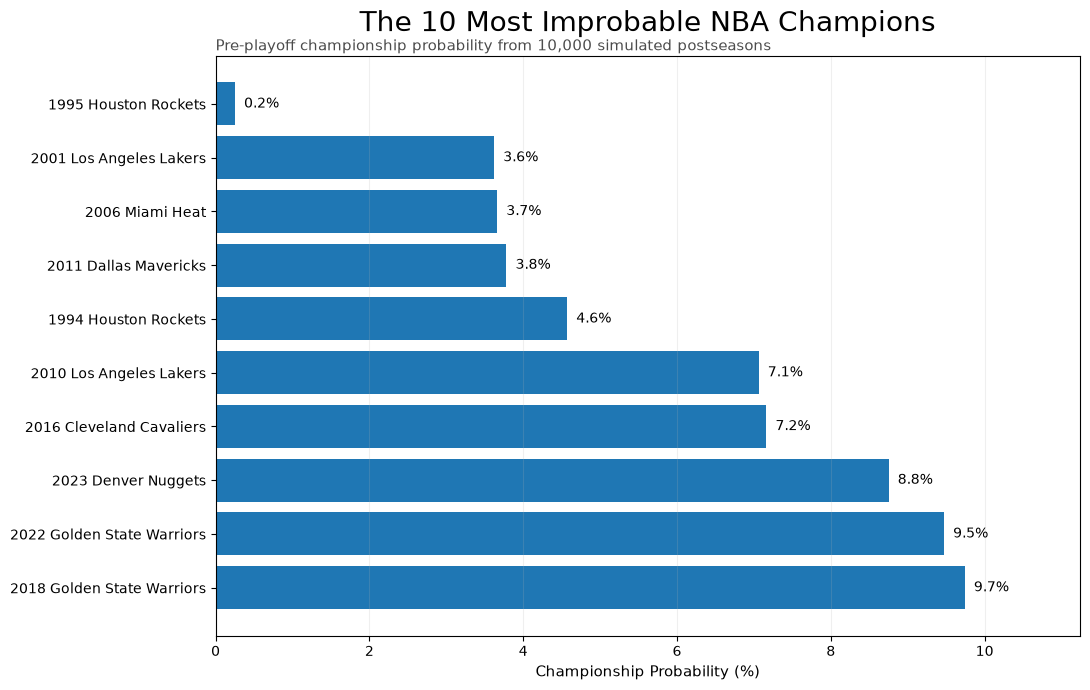

In [4]:
# ============================================================
# FIGURE 2
# 10 MOST IMPROBABLE NBA CHAMPIONS
# ============================================================

improbable = (
    champions
    .nsmallest(
        10,
        "Championship_Probability"
    )
    .sort_values(
        "Championship_Probability",
        ascending=False
    )
    .copy()
)

improbable["Label"] = (
    improbable["Season_End"].astype(str)
    + " "
    + improbable["Champion"]
)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.barh(
    improbable["Label"],
    improbable["Championship_Probability"] * 100
)

# Lowest probability appears at bottom,
# creating a visual countdown toward Houston
ax.set_title(
    "The 10 Most Improbable NBA Champions",
    fontsize=20,
    pad=18
)

ax.text(
    0,
    1.01,
    "Pre-playoff championship probability from 10,000 simulated postseasons",
    transform=ax.transAxes,
    fontsize=11,
    alpha=0.7
)

for bar, probability in zip(
    bars,
    improbable["Championship_Probability"]
):
    ax.text(
        bar.get_width() + 0.12,
        bar.get_y() + bar.get_height() / 2,
        f"{probability:.1%}",
        va="center",
        fontsize=10
    )

ax.set_xlabel(
    "Championship Probability (%)",
    fontsize=11
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    improbable["Championship_Probability"].max() * 100 + 1.5
)

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.show()

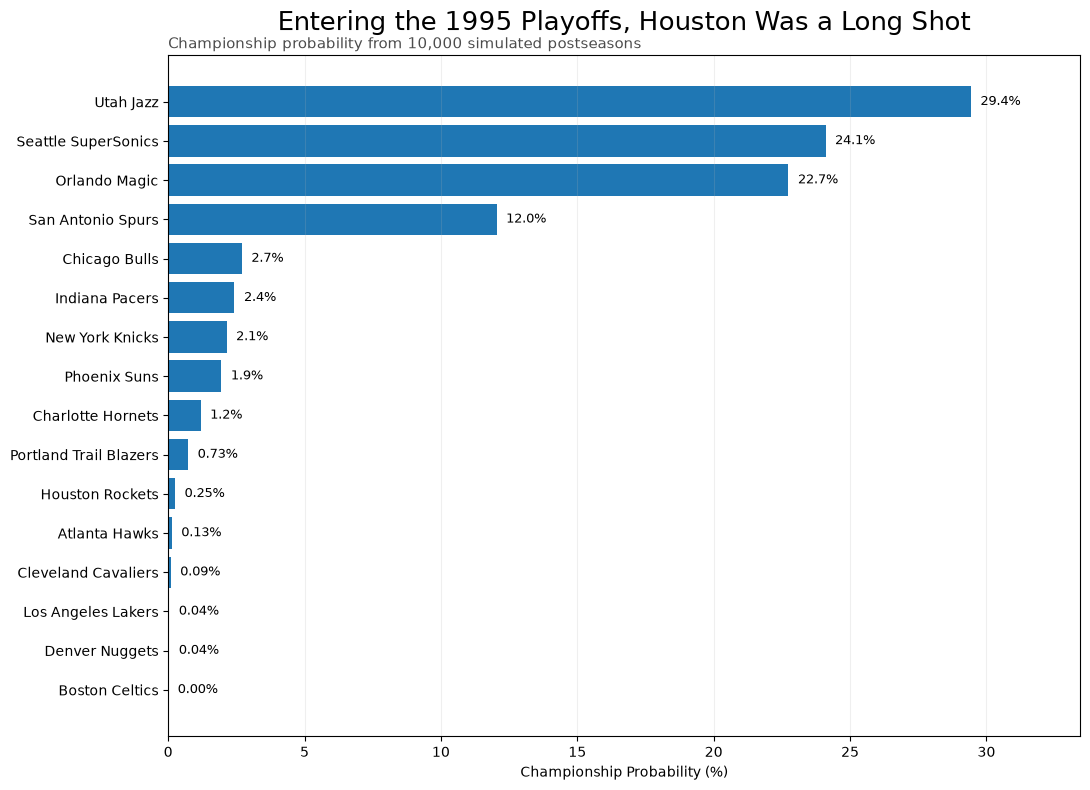

In [5]:
# ============================================================
# 1995 ROCKETS CASE STUDY
# CHAMPIONSHIP PROBABILITY OF EVERY PLAYOFF TEAM
# ============================================================

results_1995 = (
    all_results[
        all_results["Season_End"] == 1995
    ]
    .sort_values(
        "Championship_Probability",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

bars = ax.barh(
    results_1995["Team"],
    results_1995["Championship_Probability"] * 100
)

for bar, probability in zip(
    bars,
    results_1995["Championship_Probability"]
):
    # Show two decimals for tiny probabilities
    if probability < 0.01:
        label = f"{probability:.2%}"
    else:
        label = f"{probability:.1%}"

    ax.text(
        bar.get_width() + 0.35,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=9
    )

ax.set_title(
    "Entering the 1995 Playoffs, Houston Was a Long Shot",
    fontsize=19,
    pad=18
)

ax.text(
    0,
    1.01,
    "Championship probability from 10,000 simulated postseasons",
    transform=ax.transAxes,
    fontsize=11,
    alpha=0.7
)

ax.set_xlabel(
    "Championship Probability (%)"
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    results_1995[
        "Championship_Probability"
    ].max() * 100 + 4
)

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.show()

In [6]:
team_data = pd.read_csv(
    "../data/nba_team_seasons_1986_2026.csv"
)

print("Team data loaded:", team_data.shape)

Team data loaded: (1177, 31)


In [7]:
# ============================================================
# 1995 CASE STUDY — REGULAR-SEASON STRENGTH
# ============================================================

strength_1995 = (
    team_data[
        (team_data["Season_End"] == 1995) &
        (team_data["Team"].isin(results_1995["Team"]))
    ][
        ["Team", "W", "L", "SRS"]
    ]
    .merge(
        results_1995[
            ["Team", "Championship_Probability"]
        ],
        on="Team"
    )
    .sort_values(
        "SRS",
        ascending=False
    )
    .reset_index(drop=True)
)

strength_1995

,Team,W,L,SRS,Championship_Probability
0,Seattle SuperSonics,57.0,25.0,7.91,0.2410
1,Utah Jazz,60.0,22.0,7.76,0.2943
2,Orlando Magic,57.0,25.0,6.44,0.2274
3,San Antonio Spurs,62.0,20.0,5.90,0.1204
4,Chicago Bulls,47.0,35.0,4.32,0.0270
5,Phoenix Suns,59.0,23.0,3.86,0.0195
6,Portland Trail Blazers,44.0,38.0,3.80,0.0073
7,Indiana Pacers,52.0,30.0,3.35,0.0243
8,Charlotte Hornets,50.0,32.0,2.87,0.0119
9,New York Knicks,55.0,27.0,2.78,0.0214


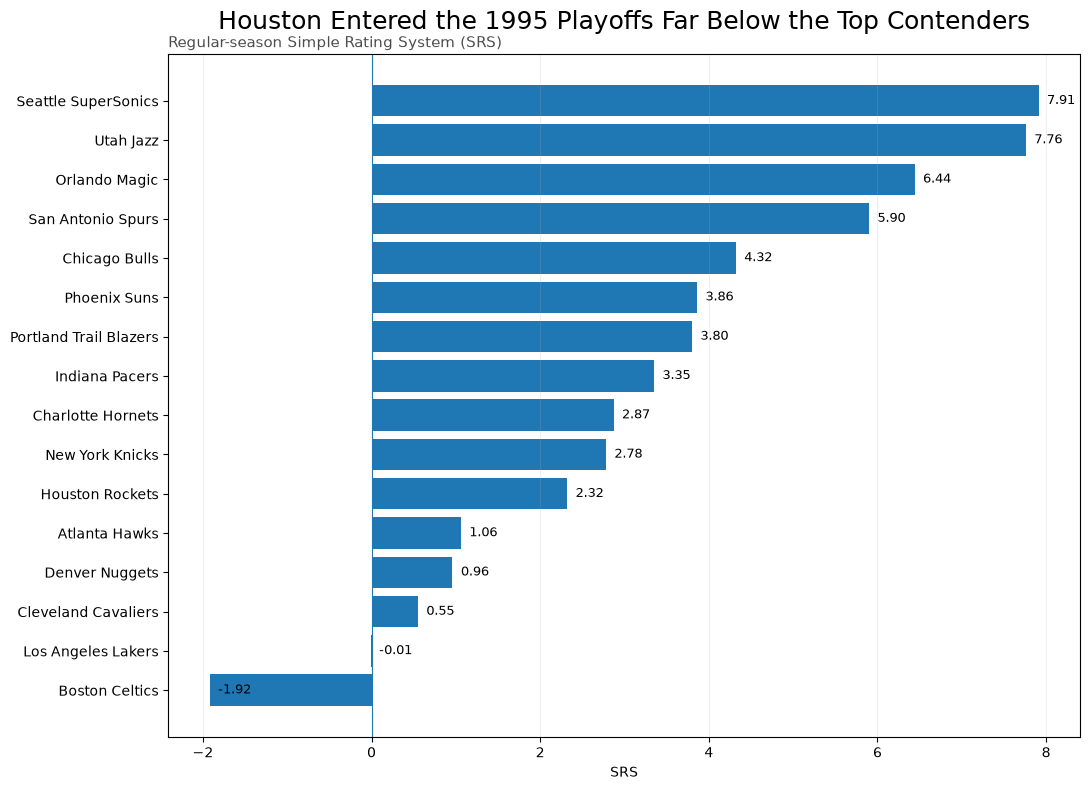

In [8]:
strength_plot = (
    strength_1995
    .sort_values("SRS", ascending=True)
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

bars = ax.barh(
    strength_plot["Team"],
    strength_plot["SRS"]
)

ax.set_title(
    "Houston Entered the 1995 Playoffs Far Below the Top Contenders",
    fontsize=18,
    pad=18
)

ax.text(
    0,
    1.01,
    "Regular-season Simple Rating System (SRS)",
    transform=ax.transAxes,
    fontsize=11,
    alpha=0.7
)

for bar, srs in zip(
    bars,
    strength_plot["SRS"]
):
    ax.text(
        bar.get_width() + 0.10,
        bar.get_y() + bar.get_height() / 2,
        f"{srs:.2f}",
        va="center",
        fontsize=9
    )

ax.axvline(
    0,
    linewidth=0.8
)

ax.set_xlabel("SRS")
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

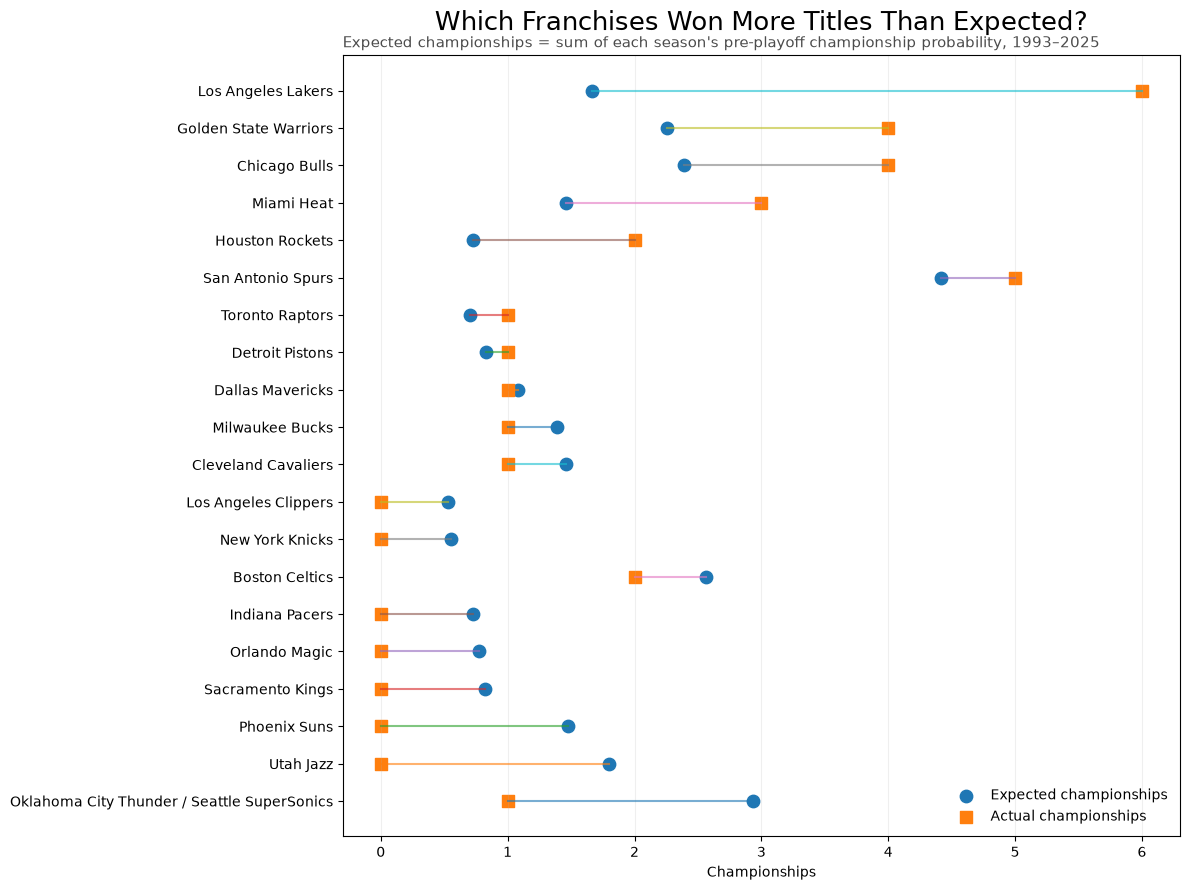

In [9]:
# ============================================================
# FIGURE 4
# EXPECTED VS ACTUAL CHAMPIONSHIPS BY FRANCHISE
# ============================================================

franchise_plot = (
    franchises[
        franchises["Expected_Championships"] >= 0.5
    ]
    .sort_values(
        "Titles_Above_Expected",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(12, 9)
)

y = np.arange(len(franchise_plot))

# Expected championships
ax.scatter(
    franchise_plot["Expected_Championships"],
    y,
    s=80,
    label="Expected championships"
)

# Actual championships
ax.scatter(
    franchise_plot["Actual_Championships"],
    y,
    s=80,
    marker="s",
    label="Actual championships"
)

# Connect expected to actual
for i, row in franchise_plot.reset_index(drop=True).iterrows():

    ax.plot(
        [
            row["Expected_Championships"],
            row["Actual_Championships"]
        ],
        [i, i],
        linewidth=1.5,
        alpha=0.6
    )

ax.set_yticks(y)

ax.set_yticklabels(
    franchise_plot["Franchise"]
)

ax.set_title(
    "Which Franchises Won More Titles Than Expected?",
    fontsize=19,
    pad=18
)

ax.text(
    0,
    1.01,
    "Expected championships = sum of each season's pre-playoff championship probability, 1993–2025",
    transform=ax.transAxes,
    fontsize=10.5,
    alpha=0.7
)

ax.set_xlabel(
    "Championships"
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.2
)

ax.legend(
    frameon=False,
    loc="lower right"
)

plt.tight_layout()

plt.show()

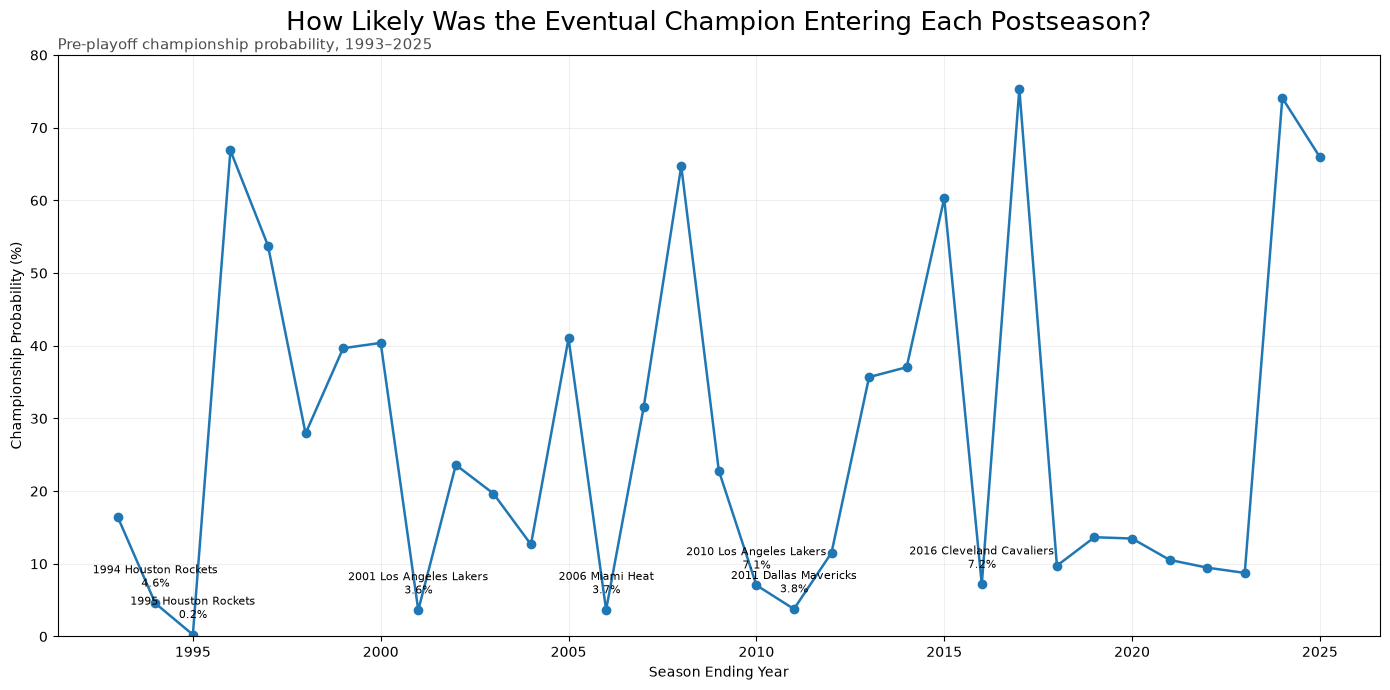

In [10]:
# ============================================================
# FIGURE 5
# CHAMPION PROBABILITY OVER TIME
# ============================================================

timeline = champions.sort_values(
    "Season_End"
).copy()

fig, ax = plt.subplots(
    figsize=(14, 7)
)

ax.plot(
    timeline["Season_End"],
    timeline["Championship_Probability"] * 100,
    marker="o",
    linewidth=1.8
)

ax.set_title(
    "How Likely Was the Eventual Champion Entering Each Postseason?",
    fontsize=19,
    pad=18
)

ax.text(
    0,
    1.01,
    "Pre-playoff championship probability, 1993–2025",
    transform=ax.transAxes,
    fontsize=11,
    alpha=0.7
)

ax.set_xlabel("Season Ending Year")
ax.set_ylabel("Championship Probability (%)")

ax.set_ylim(0, 80)

ax.grid(
    alpha=0.2
)

# Label especially improbable champions
notable = timeline[
    timeline["Championship_Probability"] < 0.08
]

for _, row in notable.iterrows():

    ax.annotate(
        f"{row['Season_End']} {row['Champion']}\n"
        f"{row['Championship_Probability']:.1%}",
        (
            row["Season_End"],
            row["Championship_Probability"] * 100
        ),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# FINAL PROJECT FINDINGS
# ============================================================

# 10 least likely actual champions
least_likely = (
    champions
    .sort_values("Championship_Probability")
    .head(10)
    [
        [
            "Season",
            "Champion",
            "Championship_Probability",
            "Simulated_Championships"
        ]
    ]
)

# 10 most likely actual champions
most_likely = (
    champions
    .sort_values(
        "Championship_Probability",
        ascending=False
    )
    .head(10)
    [
        [
            "Season",
            "Champion",
            "Championship_Probability",
            "Simulated_Championships"
        ]
    ]
)

# Biggest franchise overperformance
most_above_expected = (
    franchises
    .sort_values(
        "Titles_Above_Expected",
        ascending=False
    )
    .head(5)
)

# Biggest franchise underperformance
most_below_expected = (
    franchises
    .sort_values("Titles_Above_Expected")
    .head(5)
)


print("======================================")
print("10 LEAST LIKELY CHAMPIONS")
print("======================================")

display(
    least_likely.style.format({
        "Championship_Probability": "{:.2%}"
    })
)


print("\n======================================")
print("10 MOST LIKELY CHAMPIONS")
print("======================================")

display(
    most_likely.style.format({
        "Championship_Probability": "{:.1%}"
    })
)


print("\n======================================")
print("MOST TITLES ABOVE EXPECTED")
print("======================================")

display(
    most_above_expected.style.format({
        "Expected_Championships": "{:.2f}",
        "Titles_Above_Expected": "{:+.2f}"
    })
)


print("\n======================================")
print("MOST TITLES BELOW EXPECTED")
print("======================================")

display(
    most_below_expected.style.format({
        "Expected_Championships": "{:.2f}",
        "Titles_Above_Expected": "{:+.2f}"
    })
)

10 LEAST LIKELY CHAMPIONS


,Season,Champion,Championship_Probability,Simulated_Championships
0,1994-95,Houston Rockets,0.25%,25
1,2000-01,Los Angeles Lakers,3.62%,362
2,2005-06,Miami Heat,3.66%,366
3,2010-11,Dallas Mavericks,3.78%,378
4,1993-94,Houston Rockets,4.57%,457
5,2009-10,Los Angeles Lakers,7.06%,706
6,2015-16,Cleveland Cavaliers,7.16%,716
7,2022-23,Denver Nuggets,8.75%,875
8,2021-22,Golden State Warriors,9.47%,947
9,2017-18,Golden State Warriors,9.74%,974



10 MOST LIKELY CHAMPIONS


,Season,Champion,Championship_Probability,Simulated_Championships
32,2016-17,Golden State Warriors,75.3%,7535
31,2023-24,Boston Celtics,74.1%,7409
30,1995-96,Chicago Bulls,66.9%,6687
29,2024-25,Oklahoma City Thunder,66.0%,6595
28,2007-08,Boston Celtics,64.7%,6473
27,2014-15,Golden State Warriors,60.3%,6029
26,1996-97,Chicago Bulls,53.8%,5377
25,2004-05,San Antonio Spurs,41.0%,4101
24,1999-00,Los Angeles Lakers,40.4%,4040
23,1998-99,San Antonio Spurs,39.7%,3966



MOST TITLES ABOVE EXPECTED


,Franchise,Playoff_Appearances,Expected_Championships,Actual_Championships,Titles_Above_Expected
0,Los Angeles Lakers,24,1.66,6,+4.34
1,Golden State Warriors,12,2.25,4,+1.75
2,Chicago Bulls,18,2.39,4,+1.61
3,Miami Heat,25,1.46,3,+1.54
4,Houston Rockets,21,0.72,2,+1.28



MOST TITLES BELOW EXPECTED


,Franchise,Playoff_Appearances,Expected_Championships,Actual_Championships,Titles_Above_Expected
29,Oklahoma City Thunder / Seattle SuperSonics,21,2.93,1,-1.93
28,Utah Jazz,22,1.80,0,-1.80
27,Phoenix Suns,19,1.48,0,-1.48
26,Sacramento Kings,10,0.82,0,-0.82
25,Orlando Magic,18,0.78,0,-0.78
